# Learning 8: Agent with Tools

**Goal**: Build an LLM agent that can use tools in a graph

## What You'll Learn
- Combining LLM with tools in LangGraph
- The ReAct pattern (Reason → Act → Observe)
- Using prebuilt ToolNode

In [2]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated
import operator
from IPython.display import Image, display

llm = ChatOpenAI(model="gpt-4o-mini")
print("Setup complete!")

/Users/syedraza/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setup complete!


## The Agent Pattern

An agent is an LLM that can:
1. **Reason** about what to do
2. **Act** by calling tools
3. **Observe** tool results
4. **Repeat** until done

```
              ┌──────────────┐
              ↓              │ (tool calls)
[START] → [Agent] ──────→ [Tools]
              │
              ↓ (no tool calls)
            [END]
```

## Step 1: Define Tools

In [3]:
@tool
def add(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers together."""
    return a * b

@tool
def get_weather(city: str) -> str:
    """Get the weather for a city."""
    weather = {
        "new york": "Sunny, 72°F",
        "london": "Rainy, 55°F",
        "tokyo": "Cloudy, 68°F",
        "paris": "Sunny, 65°F"
    }
    return weather.get(city.lower(), f"Weather not available for {city}")

tools = [add, multiply, get_weather]
print("Tools defined:", [t.name for t in tools])

Tools defined: ['add', 'multiply', 'get_weather']


## Step 2: Define Agent State

We use `Annotated[list, operator.add]` to accumulate messages.

In [4]:
class AgentState(TypedDict):
    # Messages accumulate (append new ones)
    messages: Annotated[list, operator.add]

# The annotation means:
# - When you return {"messages": [new_msg]}
# - It APPENDS to existing messages (doesn't replace)

## Step 3: Create the Agent Node

In [5]:
# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

def agent_node(state: AgentState) -> dict:
    """The agent: calls the LLM with tools."""
    response = llm_with_tools.invoke(state["messages"])
    # Return the response as a new message (will be appended)
    return {"messages": [response]}

## Step 4: Create the Tool Node

LangGraph provides a prebuilt `ToolNode` that:
- Reads tool calls from the last message
- Executes the tools
- Returns tool results as messages

In [6]:
# Use the prebuilt ToolNode
tool_node = ToolNode(tools)

print("ToolNode created!")

ToolNode created!


## Step 5: Create the Router

Decides whether to call tools or finish.

In [8]:
def should_continue(state: AgentState) -> str:
    """Decide: call tools or finish?"""
    last_message = state["messages"][-1]
    
    # If there are tool calls, route to tools
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    
    # Otherwise, we're done
    return "end"

## Step 6: Build the Graph

In [9]:
# Build the agent graph
builder = StateGraph(AgentState)

# Add nodes
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

# Add edges
builder.add_edge(START, "agent")

# Conditional edge from agent
builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "end": END
    }
)

# After tools, go back to agent (the loop!)
builder.add_edge("tools", "agent")

# Compile
agent = builder.compile()

print("Agent compiled!")

Agent compiled!


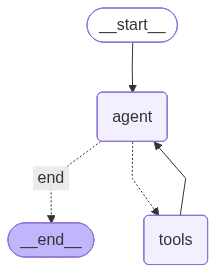

In [10]:
# Visualize
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except:
    print(agent.get_graph().draw_ascii())

## Step 7: Run the Agent!

In [11]:
# Simple calculation
result = agent.invoke({
    "messages": [HumanMessage(content="What is 5 + 3?")]
})

print("Final answer:")
print(result["messages"][-1].content)

Final answer:
5 + 3 equals 8.


In [12]:
# More complex calculation (requires multiple tool calls)
result = agent.invoke({
    "messages": [HumanMessage(content="What is (4 + 5) * 3?")]
})

print("Final answer:")
print(result["messages"][-1].content)

Final answer:
The result of (4 + 5) * 3 is 27.


In [13]:
# Weather query
result = agent.invoke({
    "messages": [HumanMessage(content="What's the weather in Tokyo?")]
})

print("Final answer:")
print(result["messages"][-1].content)

Final answer:
The weather in Tokyo is currently cloudy with a temperature of 68°F.


## Streaming the Agent

Watch the agent think and act step by step.

In [ ]:
print("Watching the agent work:")
print("=" * 50)

for step in agent.stream({
    "messages": [HumanMessage(content="What is 10 + 20, and what's the weather in Paris?")]
}):
    for node_name, output in step.items():
        print(f"\n--- {node_name.upper()} ---")
        last_msg = output["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            print("Tool calls:", last_msg.tool_calls)
        else:
            print("Content:", last_msg.content[:200] if last_msg.content else "(no content)")

## Understanding the Message Flow

In [ ]:
# See all messages in the conversation
result = agent.invoke({
    "messages": [HumanMessage(content="What is 7 * 8?")]
})

print("Complete message history:")
print("=" * 50)
for i, msg in enumerate(result["messages"]):
    msg_type = type(msg).__name__
    print(f"\n[{i}] {msg_type}:")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  Tool calls: {msg.tool_calls}")
    if hasattr(msg, "content") and msg.content:
        print(f"  Content: {msg.content}")

## Exercise: Extend the Agent

Add new tools to the agent:
1. A `divide` tool
2. A `search_database` tool (simulated)
3. Test with queries that use multiple tools

In [ ]:
# Your code here!



## Key Takeaways

1. Agents combine LLMs with tools in a loop
2. `Annotated[list, operator.add]` accumulates messages
3. `ToolNode` handles tool execution automatically
4. The agent loops: reason → act → observe → repeat
5. Streaming shows the agent's decision process

**Next**: Learning 9 - Memory & State